In [2]:
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

model.eval()

print("ResNet50 loaded!")

ResNet50 loaded!


In [3]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [4]:
target_layer = model.layer4[2].conv3
print(target_layer)

Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [5]:
print(target_layer.weight.shape)

torch.Size([2048, 512, 1, 1])


Esta Conv2d recibe 512 canales, aplica 2048 filtros con kernel espacial (1,1), stride 1 y sin bias, y produce 2048 canales de salida.  
Por eso el tensor de pesos de esta capa debería tener aproximadamente:
2048 , 512 , 1, 1

(335, 597)


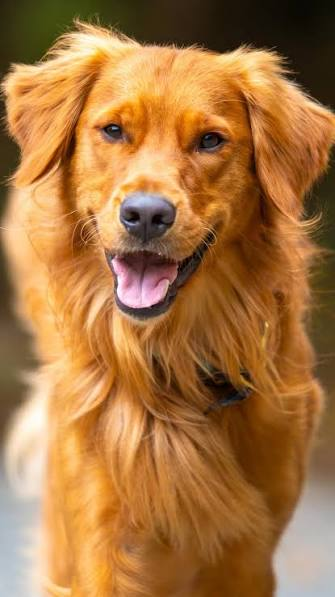

In [6]:
from PIL import Image

image = Image.open("../assets/examples/dog.jpg").convert("RGB")

print(image.size)
display(image)

In [7]:
preprocess = weights.transforms()
print(preprocess)

input_tensor = preprocess(image)

print(input_tensor.shape)

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)
torch.Size([3, 224, 224])


In [8]:
x = input_tensor.unsqueeze(0)

print(x.shape)

torch.Size([1, 3, 224, 224])


In [9]:
import torch

output = model(x)

print(output.shape)

torch.Size([1, 1000])


In [10]:
predicted_class = output.argmax(dim=1).item()

print(predicted_class)

categories = weights.meta["categories"]

print(categories[predicted_class])

207
golden retriever


In [11]:
yc = output[0, predicted_class]

print("y^c:", yc.item())

y^c: 7.209696292877197


In [12]:
activations = None
gradients = None

def save_activations(module, input, output):
    global activations, gradients
    
    activations = output
    
    def save_gradient(grad):
        global gradients
        gradients = grad
    
    output.register_hook(save_gradient)

In [13]:
handle = target_layer.register_forward_hook(save_activations)

In [14]:
# 2. NUEVO forward
output = model(x)

c = output.argmax(dim=1).item()
yc = output[0, c]

print("Class:", c)
print("Class name:", categories[c])
print("Score:", yc.item())

Class: 207
Class name: golden retriever
Score: 7.209696292877197


In [15]:
# 2. NUEVO forward
output = model(x)

c = output.argmax(dim=1).item()
yc = output[0, c]

print("Class:", c)
print("Class name:", categories[c])
print("Score:", yc.item())

Class: 207
Class name: golden retriever
Score: 7.209696292877197


In [16]:
# 3. Backward
model.zero_grad()
yc.backward()

In [17]:
print("Activations:", activations.shape)
print("Gradients:", gradients.shape)

Activations: torch.Size([1, 2048, 7, 7])
Gradients: torch.Size([1, 2048, 7, 7])


In [18]:
c = output.argmax(dim=1).item()
yc = output[0, c]

print("Class:", c)
print("Score:", yc.item())

Class: 207
Score: 7.209696292877197


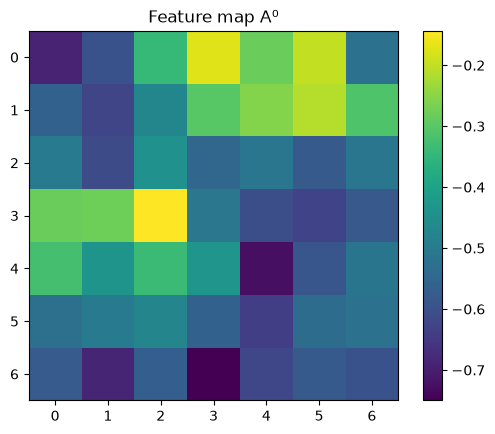

In [19]:
import matplotlib.pyplot as plt

feature_map = activations[0, 0].detach()

plt.imshow(feature_map)
plt.title("Feature map A⁰")
plt.colorbar()
plt.show()

In [20]:
# 1. Calcular α_k^c
# Promedio de los gradientes en las dimensiones espaciales 7x7
weights = gradients.mean(dim=(2, 3))

print("Weights:", weights.shape)
# [1, 2048]


# 2. Preparar los pesos para poder multiplicarlos por los feature maps
weights = weights.unsqueeze(2).unsqueeze(3)

print("Weights reshaped:", weights.shape)
# [1, 2048, 1, 1]


# 3. Multiplicar cada feature map A^k por su peso α_k^c
weighted_activations = weights * activations

print("Weighted activations:", weighted_activations.shape)
# [1, 2048, 7, 7]


# 4. SUMATORIA sobre k (los 2048 feature maps)
cam = weighted_activations.sum(dim=1)

print("CAM before ReLU:", cam.shape)
# [1, 7, 7]


# 5. Aplicar ReLU
import torch.nn.functional as F

cam = F.relu(cam)

print("CAM after ReLU:", cam.shape)
# [1, 7, 7]

Weights: torch.Size([1, 2048])
Weights reshaped: torch.Size([1, 2048, 1, 1])
Weighted activations: torch.Size([1, 2048, 7, 7])
CAM before ReLU: torch.Size([1, 7, 7])
CAM after ReLU: torch.Size([1, 7, 7])


In [21]:
# α_k^c A^k
weighted_activations = weights * activations

# Σ_k
cam = weighted_activations.sum(dim=1)

# ReLU(...)
cam = F.relu(cam)

In [22]:
cam_ours_raw = cam[0].detach().cpu().clone()

print(cam_ours_raw.shape)
print(cam_ours_raw.min().item())
print(cam_ours_raw.max().item())

torch.Size([7, 7])
0.0
0.08808514475822449


In [23]:
print(cam)

tensor([[[0.0000, 0.0000, 0.0000, 0.0095, 0.0000, 0.0347, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0429, 0.0320, 0.0881, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0076, 0.0000, 0.0474, 0.0000],
         [0.0000, 0.0000, 0.0045, 0.0364, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]]],
       grad_fn=<ReluBackward0>)


## Grad-CAM Visualization

In [24]:
cam.shape
# [1, 7, 7]

torch.Size([1, 7, 7])

In [25]:
cam_normalized = (cam - cam.min()) / (cam.max() - cam.min())

In [26]:
print("Min:", cam_normalized.min().item())
print("Max:", cam_normalized.max().item())
print("Shape:", cam_normalized.shape)

Min: 0.0
Max: 1.0
Shape: torch.Size([1, 7, 7])


In [27]:
import torch.nn.functional as F

cam_resized = F.interpolate(
    cam_normalized.unsqueeze(1),
    size=(224, 224),
    mode="bilinear",
    align_corners=False
)

print(cam_resized.shape)

torch.Size([1, 1, 224, 224])


In [28]:
heatmap = cam_resized[0, 0]

print(heatmap.shape)

torch.Size([224, 224])


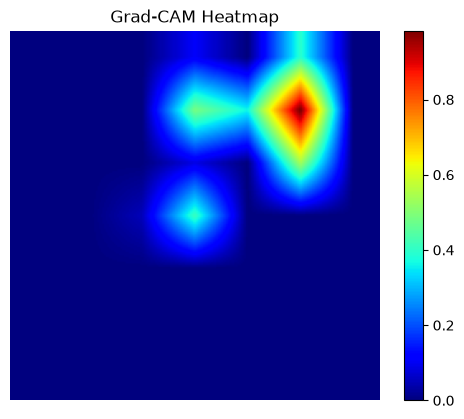

In [29]:
import matplotlib.pyplot as plt

plt.imshow(heatmap.detach().cpu(), cmap="jet")
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.show()

In [30]:
import torch

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

image_display = x[0].detach().cpu() * std + mean

# [C, H, W] -> [H, W, C]
image_display = image_display.permute(1, 2, 0)

# asegurarnos de que quede en [0,1]
image_display = image_display.clamp(0, 1)

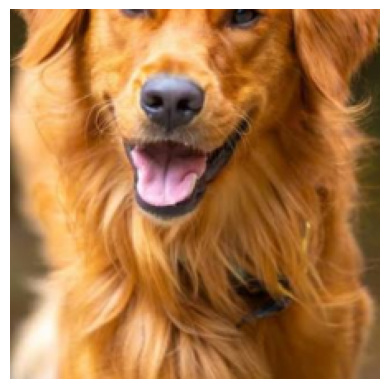

In [31]:
plt.imshow(image_display)
plt.axis("off")
plt.show()

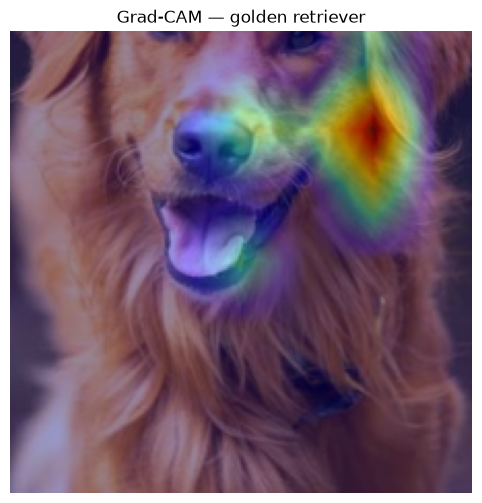

In [32]:
plt.figure(figsize=(6, 6))

# Imagen
plt.imshow(image_display)

# Grad-CAM encima
plt.imshow(
    heatmap.detach().cpu(),
    cmap="jet",
    alpha=0.4
)

plt.title(f"Grad-CAM — {categories[c]}")
plt.axis("off")
plt.show()

Para el score de la clase golden retriever, Grad-CAM muestra una mayor contribución positiva en regiones localizadas principalmente alrededor del rostro del perro.

In [33]:
%pip install grad-cam

Note: you may need to restart the kernel to use updated packages.


## Validation against reference implementation

In [34]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [35]:
target_layer = model.layer4[2].conv3

In [36]:
reference_cam = GradCAM(
    model=model,
    target_layers=[target_layer]
)

In [37]:
targets = [ClassifierOutputTarget(c)]

In [38]:
c = 207

In [39]:
grayscale_cam = reference_cam(
    input_tensor=x,
    targets=targets
)

In [40]:
cam_reference = grayscale_cam[0]

print(cam_reference.shape)

(224, 224)


In [41]:
ref_activations = reference_cam.activations_and_grads.activations[0]
ref_gradients = reference_cam.activations_and_grads.gradients[0]

print("Reference activations:", ref_activations.shape)
print("Reference gradients:", ref_gradients.shape)

Reference activations: torch.Size([1, 2048, 7, 7])
Reference gradients: torch.Size([1, 2048, 7, 7])


In [42]:
cam_ours = heatmap.detach().cpu().numpy()

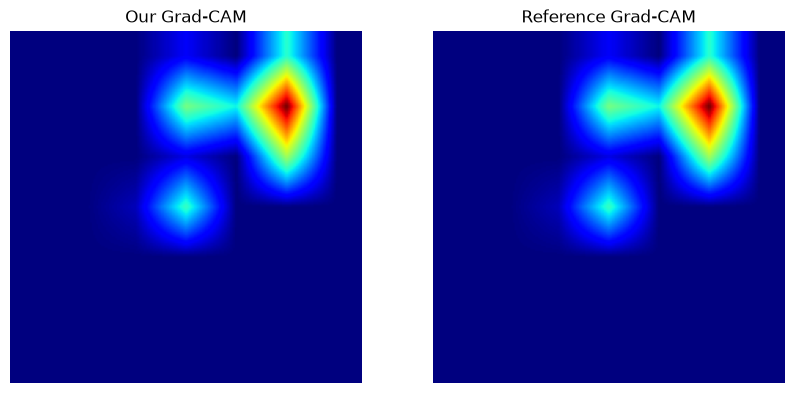

In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(cam_ours, cmap="jet")
axes[0].set_title("Our Grad-CAM")
axes[0].axis("off")

axes[1].imshow(cam_reference, cmap="jet")
axes[1].set_title("Reference Grad-CAM")
axes[1].axis("off")

plt.show()

In [44]:
import numpy as np

difference = np.abs(cam_ours - cam_reference)

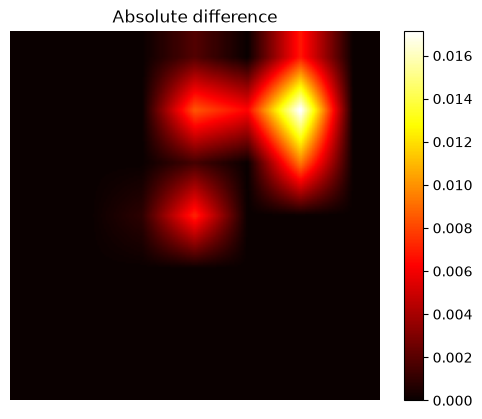

In [45]:
plt.imshow(difference, cmap="hot")
plt.colorbar()
plt.title("Absolute difference")
plt.axis("off")
plt.show()

In [46]:
print("Mean absolute difference:", difference.mean())
print("Max absolute difference:", difference.max())

Mean absolute difference: 0.0012252536
Max absolute difference: 0.017151237


In [47]:
correlation = np.corrcoef(
    cam_ours.flatten(),
    cam_reference.flatten()
)[0, 1]

print("Correlation:", correlation)

Correlation: 0.9999999999999885


### Testing the effect of normalization

In [48]:
def minmax_normalize(cam):
    return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

ours_norm = minmax_normalize(cam_ours)
ref_norm = minmax_normalize(cam_reference)

difference_norm = np.abs(ours_norm - ref_norm)

print("MAE after same normalization:", difference_norm.mean())
print("Max difference:", difference_norm.max())

correlation_norm = np.corrcoef(
    ours_norm.flatten(),
    ref_norm.flatten()
)[0, 1]

print("Correlation:", correlation_norm)

MAE after same normalization: 9.290125e-09
Max difference: 1.7881393e-07
Correlation: 0.9999999999999892


### Validation result

After applying the same min-max normalization to both maps, the mean
absolute difference decreased to approximately 9.3e-09, while the
correlation remained approximately 1.0.

This indicates that the spatial pattern produced by the implementation
from scratch is numerically equivalent to the reference implementation
up to differences in scaling/post-processing.

Comparé directamente la salida matemática de mi implementación contra la salida matemática de referencia, antes de normalización, interpolación y visualización, para verificar si dan el mismo resultado.

In [49]:
ours_A = activations.detach().cpu()
ours_G = gradients.detach().cpu()

In [50]:
ref_A = ref_activations.detach().cpu()
ref_G = ref_gradients.detach().cpu()

In [51]:
print(
    "Activation max difference:",
    (ours_A - ref_A).abs().max().item()
)

print(
    "Gradient max difference:",
    (ours_G - ref_G).abs().max().item()
)

Activation max difference: 0.0
Gradient max difference: 0.0


In [52]:
ref_alpha = ref_G.mean(dim=(2, 3))

print(ref_alpha.shape)

torch.Size([1, 2048])


In [55]:
ours_alpha = weights.squeeze(-1).squeeze(-1).detach().cpu()

print("Ours alpha:", ours_alpha.shape)
print("Reference alpha:", ref_alpha.shape)

Ours alpha: torch.Size([1, 2048])
Reference alpha: torch.Size([1, 2048])


In [56]:
print(
    "Alpha max difference:",
    (ours_alpha - ref_alpha).abs().max().item()
)

Alpha max difference: 0.0
